In [48]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection  import train_test_split
import scipy 
from ipywidgets import widgets
from IPython.display import display
import yaml

In [28]:
pd.set_option('display.max_rows', None)

# Show every column in the DataFrame
pd.set_option('display.max_columns', None)

# Show the full content within each cell (preventing long text from being cut off)
pd.set_option('display.max_colwidth', None)

# Show all items in a list inside a cell
pd.set_option('display.max_seq_items', None)


In [65]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [63]:
df = pd.read_parquet(config['data_source']['file_paths']['cleaned_dataset'])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        74777 non-null  string        
 1   city                         74779 non-null  string        
 2   district                     74779 non-null  string        
 3   area                         68237 non-null  string        
 4   neighborhood                 39763 non-null  string        
 5   property_type                74779 non-null  string        
 6   sale_or_rent                 74779 non-null  string        
 7   price                        74779 non-null  Int64         
 8   seller_name                  74779 non-null  string        
 9   property_subtype             74779 non-null  string        
 10  bedrooms                     74779 non-null  Int64         
 11  bathrooms                    74779 non-nu

In [31]:
# columns like purpose, payment option and seller_name must be investigated to see if it drive real value
for colum in ['purpose', 'payment option', 'seller_name']:
    print(f"The number of unique values in {colum} is  = {df[colum].nunique()}")
    if df[colum].nunique() <= 10:
        print(f"{colum} uniques values are {df[colum].unique()}")
        print(f"{colum} sum of null values are {df[colum].isna().sum()}")

The number of unique values in purpose is  = 2
purpose uniques values are <StringArray>
['for sale', 'for rent']
Length: 2, dtype: string
purpose sum of null values are 0
The number of unique values in payment option is  = 3
payment option uniques values are <StringArray>
['cash', 'installment', 'cash or installment', <NA>]
Length: 4, dtype: string
payment option sum of null values are 16865
The number of unique values in seller_name is  = 1632


In [32]:
# The first desicsion that I will not need both purpose and seller_name in my model 
# 1. Purpose is the same as rent_or_sale 
# 2. seller_name won't be available at inference and even if it was available it will not provide useful general information

df.drop(columns=['purpose', 'seller_name', 'price_tier', 'city','title','level_clean'], inplace=True)

In [33]:
## Therefroe we need to check wither payment plan will affect the price or not
filtered_df = df.groupby('payment option')['price'].agg(
    ['count', 'mean','median','std']
).reset_index().sort_values(by = 'count', ascending= False)
filtered_df.head()

,payment option,count,mean,median,std
0,cash,34600,16672279.824971,10000000.0,23169966.388508
1,cash or installment,12961,13510405.029859,9970000.0,11702746.876841
2,installment,10353,15274467.49831,11000000.0,13406035.532626


In [32]:
import seaborn as sns

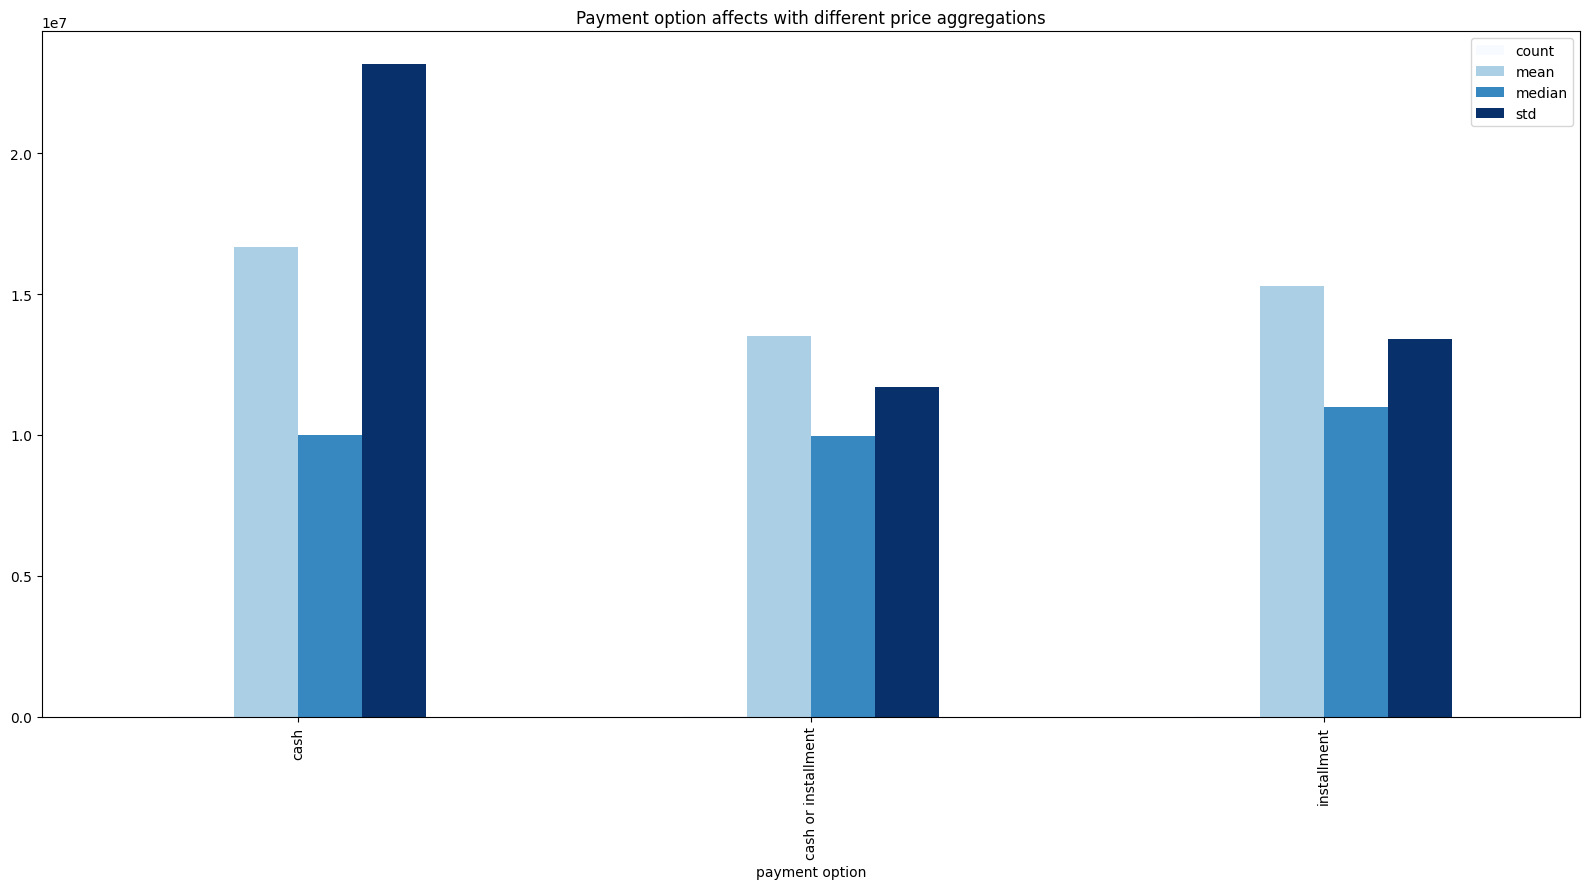

In [34]:
filtered_df.set_index('payment option')[['count', 'mean','median','std']].plot(
    kind = 'bar',
    figsize= (16,9),
     colormap='Blues'
)
plt.title('Payment option affects with different price aggregations')
plt.tight_layout()
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        74777 non-null  string        
 1   city                         74779 non-null  string        
 2   district                     74779 non-null  string        
 3   area                         68237 non-null  string        
 4   neighborhood                 39763 non-null  string        
 5   property_type                74779 non-null  string        
 6   sale_or_rent                 74779 non-null  string        
 7   price                        74779 non-null  Int64         
 8   property_subtype             74779 non-null  string        
 9   bedrooms                     74779 non-null  Int64         
 10  bathrooms                    74779 non-null  Int64         
 11  ownership                    47148 non-nu

water meter
1    44131
0    30648
Name: count, dtype: int64

In [40]:
## Most of our columns are either strings or bool so let's create a function that changes the every bool column 
## Into 0 or 1 better than one-hot-encoding 
def engineer_bool_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    

    df[bool_cols] = df[bool_cols].astype('int')
    return df
bool_cleaned_df = engineer_bool_columns(df)
bool_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   district                     74779 non-null  string        
 1   area                         68237 non-null  string        
 2   neighborhood                 39763 non-null  string        
 3   property_type                74779 non-null  string        
 4   sale_or_rent                 74779 non-null  string        
 5   price                        74779 non-null  Int64         
 6   property_subtype             74779 non-null  string        
 7   bedrooms                     74779 non-null  Int64         
 8   bathrooms                    74779 non-null  Int64         
 9   ownership                    47148 non-null  string        
 10  payment option               57914 non-null  string        
 11  furnished                    62123 non-nu

In [22]:
# Now the string columns 
string_cols = df.select_dtypes(include='string').columns.tolist()
for col in string_cols:
    print(f'{col} have {df[col].nunique()} values with {df[col].isnull().sum()} null values')

district have 39 values with 0 null values
area have 293 values with 6542 null values
neighborhood have 116 values with 35016 null values
property_type have 2 values with 0 null values
sale_or_rent have 2 values with 0 null values
property_subtype have 11 values with 0 null values
ownership have 2 values with 27631 null values
payment option have 3 values with 16865 null values
furnished have 2 values with 12656 null values
completion status have 2 values with 16807 null values
delivery term have 6 values with 54353 null values
rental frequency have 4 values with 57972 null values


In [13]:
df['delivery term'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 74779 entries, 0 to 74778
Series name: delivery term
Non-Null Count  Dtype 
--------------  ----- 
20426 non-null  string
dtypes: string(1)
memory usage: 584.3 KB


In [11]:
df[df['sale_or_rent'] == 'sale']['delivery term'].info()

<class 'pandas.core.series.Series'>
Index: 57972 entries, 0 to 74425
Series name: delivery term
Non-Null Count  Dtype 
--------------  ----- 
19489 non-null  string
dtypes: string(1)
memory usage: 905.8 KB


In [17]:
df['delivery term'].unique()

<StringArray>
[           <NA>,      'finished', 'semi finished',  'core & shell',
 'semi_finished',  'not finished']
Length: 6, dtype: string

In [38]:
# As it very important feature and it's so informative I will make all the null values in it as Unkown and will be treated as it's own categore
bool_cleaned_df['delivery term'] = bool_cleaned_df['delivery term'].replace('not_finished', 'not finished')
bool_cleaned_df['delivery term'] = bool_cleaned_df['delivery term'].replace('semi_finished', 'semi finished')
bool_cleaned_df['delivery term'] = bool_cleaned_df['delivery term'].fillna('Unkown')
bool_cleaned_df['delivery term'].value_counts()

delivery term
Unkown           54353
finished         16280
semi finished     2438
not finished       880
core & shell       828
Name: count, dtype: Int64

In [41]:
string_cols = bool_cleaned_df.select_dtypes(include='string').columns.tolist()
one_hot_columns =  []
for col in string_cols:
    if col == 'property_type' or col== 'sale_or_rent':
        continue
    if bool_cleaned_df[col].nunique() < 40:
        one_hot_columns.append(col)
    
encoded_df = pd.get_dummies(bool_cleaned_df, columns=one_hot_columns)
encoded_df = engineer_bool_columns(encoded_df)

encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74779 entries, 0 to 74778
Data columns (total 94 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   area                                68237 non-null  string        
 1   neighborhood                        39763 non-null  string        
 2   property_type                       74779 non-null  string        
 3   sale_or_rent                        74779 non-null  string        
 4   price                               74779 non-null  Int64         
 5   bedrooms                            74779 non-null  Int64         
 6   bathrooms                           74779 non-null  Int64         
 7   deposit                             3769 non-null   Int64         
 8   insurance                           3711 non-null   Int64         
 9   electricity meter                   74779 non-null  int64         
 10  water meter           

In [43]:
strings_cols = encoded_df.select_dtypes(include='string').columns.tolist()

In [44]:
for col in strings_cols:
    print(f"{col} have {encoded_df[col].nunique()} unique values")

area have 293 unique values
neighborhood have 116 unique values
property_type have 2 unique values
sale_or_rent have 2 unique values


In [ ]:
# Next step deal with high cardinality features
encoded_df.head()


,area,neighborhood,price,bedrooms,bathrooms,deposit,insurance,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),district_15 May City,district_Abasiya,district_Ain Shams,district_Al Manial,district_Almazah,district_Badr City,district_Basateen,district_Downtown Cairo,district_El Fostat,district_Garden City,district_Gesr Al Suez,district_Hadayek Helwan,district_Hadayek al-Kobba,district_Hadayeq El Zeitoun,district_Heliopolis,district_Helmeyat El Zaytoun,district_Helwan,district_Katameya,district_Maadi,district_Madinaty,district_Marg,district_Masr al-Kadema,district_Matareya,district_Mokattam,district_Mostakbal City,district_Nasr City,district_New Cairo,district_New Capital City,district_New Heliopolis,district_New Nozha,district_Nozha,district_Obour City,district_Rod al-Farag,district_Salam City,district_Sheraton,district_Shorouk City,district_Shubra,district_Zahraa Al Maadi,district_Zamalek,property_type_apartments,property_type_villas,sale_or_rent_rent,sale_or_rent_sale,property_subtype_Apartment,property_subtype_Duplex,property_subtype_Hotel Apartment,property_subtype_Penthouse,property_subtype_Roof,property_subtype_Room,property_subtype_Stand Alone Villa,property_subtype_Studio,property_subtype_Town House,property_subtype_Twin House,property_subtype_iVilla,ownership_primary,ownership_resale,payment option_cash,payment option_cash or installment,payment option_installment,furnished_no,furnished_yes,completion status_off-plan,completion status_ready,delivery term_Unkown,delivery term_core & shell,delivery term_finished,delivery term_not finished,delivery term_semi finished,rental frequency_daily,rental frequency_monthly,rental frequency_weekly,rental frequency_yearly
0,5th Settlement,Hyde Park New Cairo Compound,13000000,3,3,<NA>,<NA>,1,1,1,1,1,0,1,0,0,1,0,1,0,0,2026-04-21,207.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0
1,5th Settlement,Hyde Park New Cairo Compound,13000000,3,3,<NA>,<NA>,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-04-21,207.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,1,0,0,0,0,0,0,0,0
2,5th Settlement,Hyde Park New Cairo Compound,7815300,2,2,<NA>,<NA>,1,1,1,1,0,1,0,1,1,1,0,1,0,0,2026-04-21,113.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,0,0
3,5th Settlement,Hyde Park New Cairo Compound,11500000,3,3,<NA>,<NA>,0,0,0,0,1,0,1,0,0,0,0,0,0,0,2026-04-21,221.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0
4,5th Settlement,Hyde Park New Cairo Compound,17000000,3,3,<NA>,<NA>,1,1,1,1,1,1,1,1,1,1,1,1,0,1,2026-04-14,170.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,0


In [ ]:
## From now on there well be frequency encoding so this must be hanled seprately for each of the 4 splited datasets 


In [101]:
## Since this is the start of feature engineering this dataset well be split across 4 categories 
## apartemen_sale, apartement_rent, villas_sale and villas_rent
dfs = {}
for type in encoded_df['property_type'].unique():
    for transaction in encoded_df['sale_or_rent'].unique():
        resulted_df = encoded_df[ (encoded_df['property_type'] == type)  & (encoded_df['sale_or_rent'] == transaction)]
        if transaction == 'sale':
            resulted_df.drop(columns = ['sale_or_rent', 'property_type','rental frequency_daily', 'rental frequency_monthly',	'rental frequency_weekly',	'rental frequency_yearly', 'deposit', 'insurance'], inplace = True)
        else:
            resulted_df.drop(columns = ['sale_or_rent', 'property_type','completion status_ready', 'completion status_off-plan'], inplace = True)
        key = type+"_"+transaction
        dfs[key] = resulted_df
print(len(dfs))

4


C:\Users\marwa\AppData\Local\Temp\ipykernel_12796\3331541444.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resulted_df.drop(columns = ['sale_or_rent', 'property_type','rental frequency_daily', 'rental frequency_monthly',	'rental frequency_weekly',	'rental frequency_yearly', 'deposit', 'insurance'], inplace = True)
C:\Users\marwa\AppData\Local\Temp\ipykernel_12796\3331541444.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resulted_df.drop(columns = ['sale_or_rent', 'property_type','completion status_ready', 'completion status_off-plan'], inplace = True)
C:\Users\marwa\AppData\Local\Temp\ipykernel_12796\333154

In [102]:

splited_train = {}
splited_test = {}
for key, value in dfs.items():
    paths = []
    for val in ['train', 'test']:
        paths.append(config['data_source']['file_paths']['cleaned_data_directory']+key +'_'+val+'.parquet') 
        # print(paths)
    
    train, test = train_test_split(value, test_size= 0.2, random_state=42)
    train.to_parquet(paths[0])
    test.to_parquet(paths[1])
    splited_train[key+'_'+'train'] = train
    splited_test[key+'_'+'test'] = test
print(splited_train.keys() , print(len(splited_train.keys())))


4
dict_keys(['apartments_sale_train', 'apartments_rent_train', 'villas_sale_train', 'villas_rent_train']) None


In [103]:
# Let's begin spilted_train 
import json 
encoded_dfs = {}
for key, val in splited_train.items():
    print(key)
    for col in ['area', 'neighborhood']:
        freq_map = val[col].value_counts(normalize = True).to_dict()
        with open(f"../data/{key}.json", "w") as json_file:
            json.dump(freq_map, json_file)
        val[col+'_encoded'] = val[col].map(freq_map)
        print(val[col+'_encoded'].value_counts())
        encoded_dfs[key] = val


apartments_sale_train
area_encoded
0.431777    13006
0.077551     2336
0.046810     1410
0.037979     1144
0.036253     1092
0.011785      710
0.023504      708
0.022708      684
0.017197      518
0.013213      398
0.013014      392
0.012283      370
0.012117      365
0.009760      294
0.009362      282
0.007636      230
0.007237      218
0.007038      212
0.006208      187
0.005710      172
0.005677      171
0.005212      157
0.001660      150
0.004947      149
0.004714      142
0.002324      140
0.004548      137
0.004316      130
0.002091      126
0.004083      123
0.004050      122
0.001859      112
0.001228      111
0.003685      111
0.003552      107
0.003519      106
0.003386      102
0.003320      100
0.000830      100
0.003187       96
0.003054       92
0.001494       90
0.000332       90
0.002921       88
0.000730       88
0.001461       88
0.001428       86
0.000564       85
0.000930       84
0.002755       83
0.002722       82
0.000664       80
0.002556       77
0.002457   

In [104]:
encoded_dfs['apartments_sale_train'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 31842 entries, 7323 to 15795
Data columns (total 88 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   area                                30122 non-null  string        
 1   neighborhood                        16509 non-null  string        
 2   price                               31842 non-null  Int64         
 3   bedrooms                            31842 non-null  Int64         
 4   bathrooms                           31842 non-null  Int64         
 5   electricity meter                   31842 non-null  int64         
 6   water meter                         31842 non-null  int64         
 7   covered parking                     31842 non-null  int64         
 8   natural gas                         31842 non-null  int64         
 9   security                            31842 non-null  int64         
 10  pets allowed            